In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
from astropy.io import fits
from matplotlib import pyplot as plt

#from pipeline_config import MAPS_DIR

In [2]:
datasets = [
    {
        "instrument": "MUSE",
        "line": "Halpha",
        "filename": "MUSE-M42-H-bin0.fits",
        "label": r"H$\alpha$",
    },
    {
        "instrument": "MUSE",
        "line": "NII_6583",
        "filename": "MUSE-M42-N-bin0.fits",
        "label": r"[N II] $\lambda$6583",
    },
    {
        "instrument": "MUSE",
        "line": "OIII_5007",
        "filename": "MUSE-M42-O-bin0.fits",
        "label": r"[O III] $\lambda$5007",
    },
    {
        "instrument": "MUSE",
        "line": "SIII_9069",
        "filename": "MUSE-M42-S-bin0.fits",
        "label": r"[S III] $\lambda$9069",
    },
    {
        "instrument": "MUSE",
        "line": "ArIII_7136",
        "filename": "MUSE-M42-Ar-bin0.fits",
        "label": r"[Ar III] $\lambda$7136",
    },

    {
        "instrument": "KPNO",
        "line": "Halpha",
        "filename": "KPNO-M42-H-bin0.fits",
        "label": r"H$\alpha$",
    },
    {
        "instrument": "KPNO",
        "line": "NII_6583",
        "filename": "KPNO-M42-N-bin0.fits",
        "label": r"[N II] $\lambda$6583",
    },
    {
        "instrument": "KPNO",
        "line": "OIII_5007",
        "filename": "KPNO-M42-O-bin0.fits",
        "label": r"[O III] $\lambda$5007",
    },
    {
        "instrument": "KPNO",
        "line": "SII_6731",
        "filename": "KPNO-M42-S-bin0.fits",
        "label": r"[S II] $\lambda$6731",
    },
]

In [3]:
def load_velocity_dataset(entry):
    fits_path = entry["filename"]

    with fits.open(fits_path) as hdul:
        sb = hdul["MOM0"].data.astype(float)
        vv = hdul["MOM1"].data.astype(float)
        mask = hdul["MASK"].data.astype(bool)

    sb = np.where(mask, sb, np.nan)
    vv = np.where(mask, vv, np.nan)

    df = pd.DataFrame({
        "X": np.indices(vv.shape)[0].ravel(),
        "Y": np.indices(vv.shape)[1].ravel(),
        "VV": vv.ravel(),
        "SB": sb.ravel(),
        "mask": mask.ravel(),
    })

    df = df.dropna(subset=["VV"])

    df["instrument"] = entry["instrument"]
    df["line"] = entry["line"]
    df["label"] = entry["label"]
    df["filename"] = entry["filename"]

    mean_v = df["VV"].mean()
    df["RV_centered"] = df["VV"] - mean_v

    raw = {
        "sb": sb,
        "vv": vv,
        "mask": mask,
        "instrument": entry["instrument"],
        "line": entry["line"],
        "label": entry["label"],
        "filename": entry["filename"],
    }

    return df, raw

In [4]:
processed_list = []
raw_data = {}

for entry in datasets:
    df, raw = load_velocity_dataset(entry)
    processed_list.append(df)

    key = (entry["line"], entry["instrument"])
    raw_data[key] = raw

processed_data = pd.concat(processed_list, ignore_index=True)

In [5]:
processed_data.head()

,X,Y,VV,SB,mask,instrument,line,label,filename,RV_centered
0,0,586,15.751118,0.032778,True,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin0.fits,1.896868
1,0,587,11.852624,0.031848,True,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin0.fits,-2.001627
2,0,588,13.774124,0.031479,True,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin0.fits,-0.080127
3,0,589,13.751033,0.031470,True,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin0.fits,-0.103217
4,0,590,15.939659,0.030806,True,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin0.fits,2.085409


In [6]:
processed_data.groupby(["line", "instrument"])["VV"].describe()

count       mean       std        min        25%  \
line       instrument                                                         
ArIII_7136 MUSE        2187357.0  30.202499  3.517950   5.042416  27.863085   
Halpha     KPNO         179958.0  16.824079  2.955181   6.030076  15.032312   
           MUSE        2188334.0  13.854251  2.832606   5.001098  11.989459   
NII_6583   KPNO         179862.0  20.530379  2.779798   9.205535  18.619456   
           MUSE        2187655.0  16.961477  3.059458   0.025481  14.855992   
OIII_5007  KPNO         180156.0  16.273105  2.760222   6.216364  14.675316   
           MUSE        2183754.0  10.445215  2.935090   0.001240   8.581722   
SIII_9069  MUSE        2186461.0  17.025315  3.029183   0.070535  14.985147   
SII_6731   KPNO         130572.0  21.268425  2.487448  14.372275  19.635127   

                             50%        75%        max  
line       instrument                                   
ArIII_7136 MUSE        30.235043  32.543522  54.930544  
Halpha     KPNO        17.231346  18.866439  24.722612  
           MUSE        13.774032  15.694070  27.988148  
NII_6583   KPNO        20.300196  21.973510  31.288391  
           MUSE        16.825457  18.905353  34.992895  
OIII_5007  KPNO        16.130953  18.043018  25.508438  
           MUSE        10.399933  12.254722  24.995433  
SIII_9069  MUSE        17.010572  19.062602  34.996606  
SII_6731   KPNO        21.047139  22.484063  31.729561

In [7]:
instrument_colors = {
    "MUSE": "black",
    "KPNO": "darkgray",
}

line_order = [
    "Halpha",
    "NII_6583",
    "OIII_5007",
    "SIII_9069",
    "SII_6731",
    "ArIII_7136",
]

In [8]:
def plot_velocity_histograms(
    data,
    line_order=None,
    binwidth=1,
    xlim=(-15, 15),
    log_scale=False,
    savepath=None,
):
    if line_order is None:
        line_order = list(data["line"].drop_duplicates())

    n_plots = len(line_order)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes).flatten()

    for ax, line in zip(axes, line_order):
        line_df = data[data["line"] == line]

        if line_df.empty:
            ax.set_visible(False)
            continue

        label = line_df["label"].iloc[0]

        for instrument in ["MUSE", "KPNO"]:
            inst_df = line_df[line_df["instrument"] == instrument]

            if inst_df.empty:
                continue

            sns.histplot(
                data=inst_df,
                x="RV_centered",
                binwidth=binwidth,
                element="step",
                fill=False,
                stat="density",
                color=instrument_colors[instrument],
                label=instrument,
                ax=ax,
            )

        if log_scale:
            ax.set_yscale("log")

        ax.set_xlim(*xlim)
        ax.set_xlabel("Radial velocity relative to mean [km/s]")
        ax.set_title(label, fontsize=12)
        ax.legend(frameon=False)

        stats_lines = []
        for instrument in ["MUSE", "KPNO"]:
            inst_df = line_df[line_df["instrument"] == instrument]

            if inst_df.empty:
                continue

            stats_lines.append(
                rf"{instrument}: $\sigma={inst_df['RV_centered'].std():.2f}$, "
                rf"$\langle V\rangle={inst_df['VV'].mean():.2f}$"
            )

        ax.text(
            0.98,
            0.95,
            "\n".join(stats_lines),
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
        )

    for i in range(n_plots, len(axes)):
        fig.delaxes(axes[i])

    axes[0].set_ylabel("Density")
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")

    plt.show()

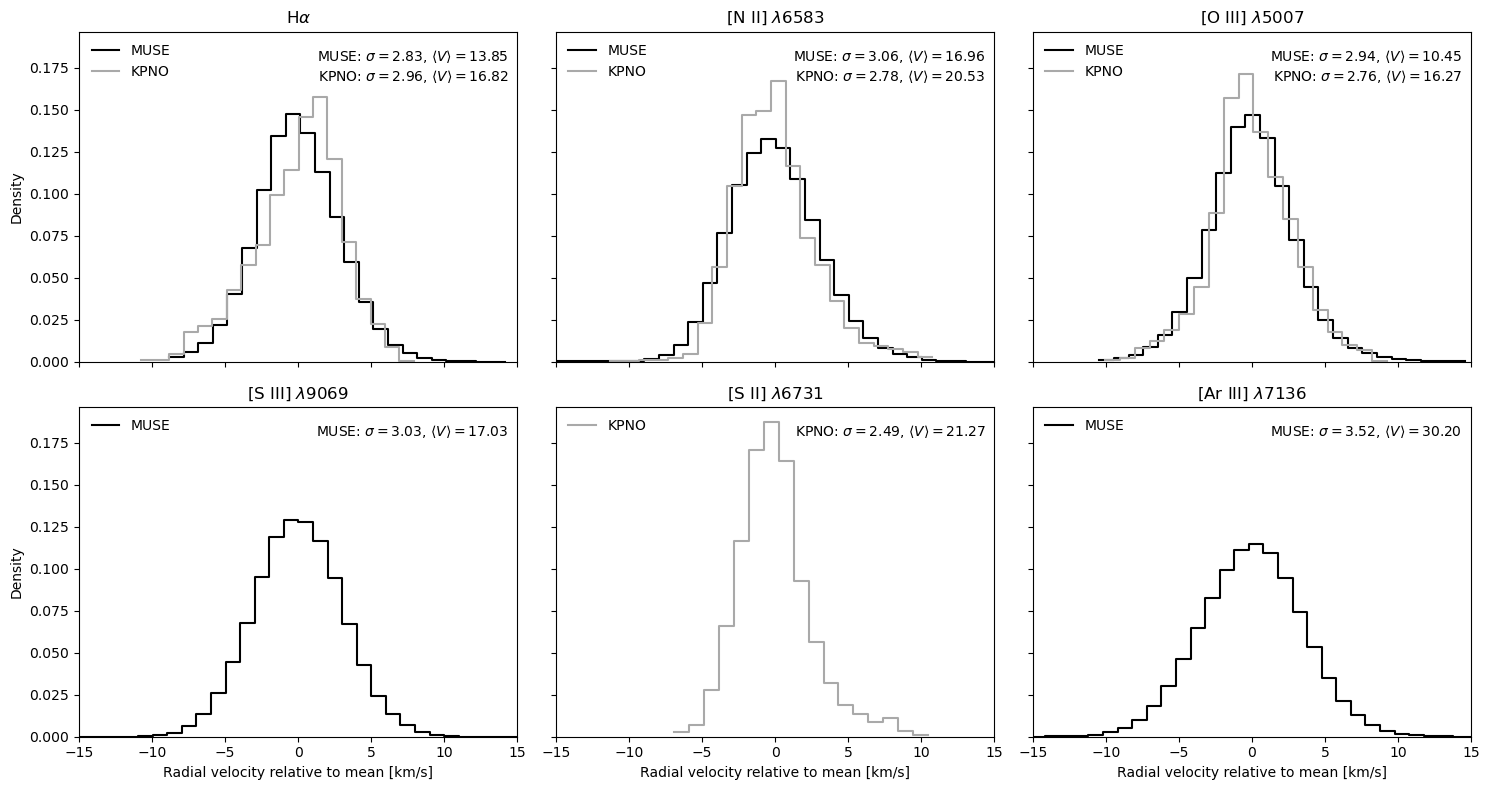

In [9]:
plot_velocity_histograms(
    processed_data,
    line_order=line_order,
    binwidth=1,
    xlim=(-15, 15),
    log_scale=False,
    savepath="Imgs/MUSE_KPNO_velocity_histograms.pdf",
)

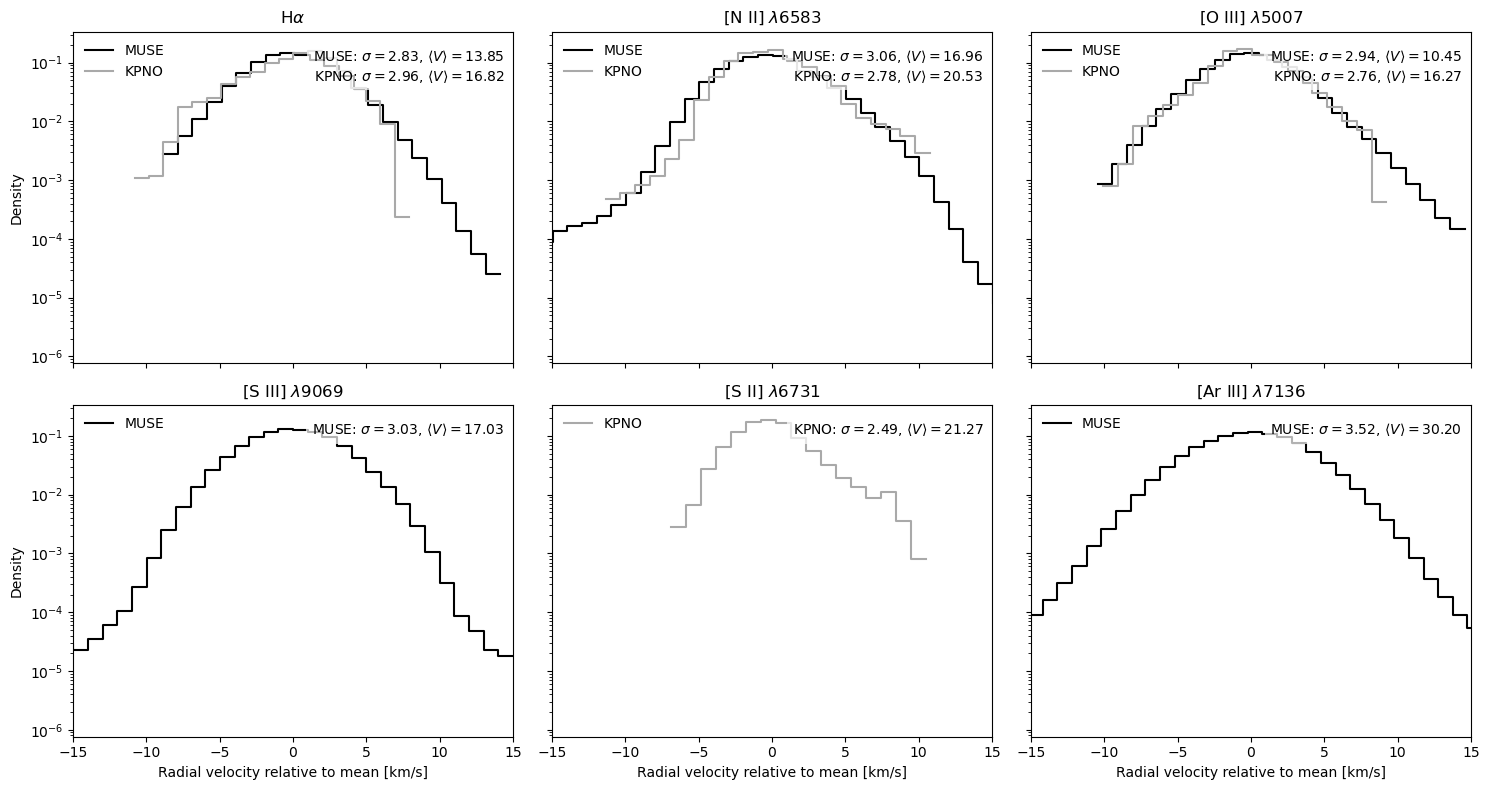

In [10]:
plot_velocity_histograms(
    processed_data,
    line_order=line_order,
    binwidth=1,
    xlim=(-15, 15),
    log_scale=True,
    savepath="Imgs/MUSE_KPNO_velocity_histograms.pdf",
)